# move data drive to colab

In [ ]:
cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content/data_processed

In [ ]:
from __future__ import annotations

# Giới hạn thread nội bộ của NumPy/OpenCV để tránh 12 worker
# đồng thời tạo thêm quá nhiều thread con.
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import hashlib
import time
from typing import Final

import cv2
import numpy as np
from tqdm import tqdm


# ============================================================
# CẤU HÌNH
# ============================================================

# Thư mục ảnh gốc, bên trong có 3 thư mục nhãn.
#
# Ví dụ:
# original_dataset/
# ├── COVID/
# ├── NORMAL/
# └── VIRAL_PNEUMONIA/
INPUT_ROOT = Path(
    r"/content/data_processed"
)

# Thư mục cha chứa hai bộ dữ liệu đầu ra.
OUTPUT_ROOT = Path(
    r"/content/simple_non_learnable_baselines"
)

# Kết quả sẽ được lưu tại:
# OUTPUT_ROOT/B1_gaussian_noise/...
# OUTPUT_ROOT/B2_random_block_permutation/...
B1_OUTPUT_ROOT = OUTPUT_ROOT / "B1_gaussian_noise"
B2_OUTPUT_ROOT = OUTPUT_ROOT / "B2_random_block_permutation"

# Số luồng xử lý.
MAX_WORKERS: Final[int] = 12

# Seed chung để kết quả có thể tái lập.
BASE_SEED: Final[int] = 2024

# ------------------------------------------------------------
# B1: Gaussian noise
# ------------------------------------------------------------

# Độ lệch chuẩn trên thang cường độ 0-255.
# Có thể thử thêm sigma = 10, 20, 30 trên validation set.
GAUSSIAN_SIGMA: Final[float] = 20.0

# ------------------------------------------------------------
# B2: Random block permutation
# ------------------------------------------------------------

# Nên dùng cùng block size với chaos-based scrambling của A3.
BLOCK_SIZE: Final[int] = 16

# False:
#   Tất cả ảnh cùng kích thước dùng cùng một block permutation.
#   Đây là lựa chọn được khuyến nghị để representation vẫn nhất quán
#   và mô hình có thể học được.
#
# True:
#   Mỗi ảnh dùng một permutation khác nhau.
BLOCK_PER_IMAGE: Final[bool] = False

# ------------------------------------------------------------
# Lưu ảnh
# ------------------------------------------------------------

# True: lưu dưới dạng PNG lossless để tránh nhiễu do nén JPEG.
# Cấu trúc thư mục vẫn giữ nguyên, chỉ đổi phần mở rộng sang .png.
#
# False: giữ nguyên phần mở rộng của ảnh gốc.
SAVE_AS_PNG: Final[bool] = True

PNG_COMPRESSION: Final[int] = 3
JPEG_QUALITY: Final[int] = 95

# Ghi đè ảnh đã tồn tại.
OVERWRITE: Final[bool] = False

# Nạp toàn bộ byte ảnh vào RAM trước khi xử lý.
PRELOAD_TO_RAM: Final[bool] = True

SUPPORTED_EXTENSIONS: Final[set[str]] = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


# Tắt multi-thread nội bộ của OpenCV.
# Ta sử dụng 12 worker bên ngoài thay vì để mỗi worker tự sinh thêm thread.
cv2.setNumThreads(1)
cv2.ocl.setUseOpenCL(False)


# ============================================================
# HÀM HỖ TRỢ
# ============================================================

def stable_seed(text: str) -> int:
    """
    Tạo seed ổn định từ chuỗi.

    Không dùng hash() của Python vì hash() có thể thay đổi giữa
    các lần chạy chương trình.
    """
    digest = hashlib.blake2b(
        text.encode("utf-8"),
        digest_size=8,
    ).digest()

    return int.from_bytes(digest, byteorder="little") % (2**32)


def is_subpath(child: Path, parent: Path) -> bool:
    """Kiểm tra child có nằm bên trong parent hay không."""
    try:
        child.resolve().relative_to(parent.resolve())
        return True
    except ValueError:
        return False


def find_images(root: Path) -> list[Path]:
    """Tìm đệ quy toàn bộ ảnh hợp lệ."""
    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )


def decode_image(image_bytes: bytes) -> np.ndarray:
    """Giải mã byte ảnh bằng OpenCV."""
    buffer = np.frombuffer(image_bytes, dtype=np.uint8)

    image = cv2.imdecode(
        buffer,
        cv2.IMREAD_UNCHANGED,
    )

    if image is None:
        raise ValueError("OpenCV không thể giải mã ảnh.")

    return image


def output_relative_path(relative_path: Path) -> Path:
    """Giữ nguyên relative path, tùy chọn đổi sang PNG."""
    if SAVE_AS_PNG:
        return relative_path.with_suffix(".png")

    return relative_path


def encode_image(
    image: np.ndarray,
    output_path: Path,
) -> bytes:
    """Mã hóa ảnh trước khi ghi xuống ổ đĩa."""
    extension = output_path.suffix.lower()

    if SAVE_AS_PNG:
        extension = ".png"
        parameters = [
            cv2.IMWRITE_PNG_COMPRESSION,
            PNG_COMPRESSION,
        ]

    elif extension in {".jpg", ".jpeg"}:
        parameters = [
            cv2.IMWRITE_JPEG_QUALITY,
            JPEG_QUALITY,
        ]

    elif extension == ".png":
        parameters = [
            cv2.IMWRITE_PNG_COMPRESSION,
            PNG_COMPRESSION,
        ]

    else:
        parameters = []

    success, encoded = cv2.imencode(
        extension,
        image,
        parameters,
    )

    if not success:
        raise ValueError(
            f"Không thể mã hóa ảnh sang định dạng {extension}"
        )

    return encoded.tobytes()


def save_image(
    image: np.ndarray,
    output_path: Path,
) -> None:
    """
    Ghi ảnh theo cơ chế tạm thời rồi replace để hạn chế file hỏng
    nếu chương trình bị dừng giữa chừng.
    """
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    encoded_bytes = encode_image(
        image=image,
        output_path=output_path,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    temporary_path.write_bytes(encoded_bytes)
    temporary_path.replace(output_path)


# ============================================================
# B1: GAUSSIAN NOISE ONLY
# ============================================================

def apply_gaussian_noise(
    image: np.ndarray,
    sigma: float,
    seed: int,
) -> np.ndarray:
    """
    Chỉ thêm Gaussian noise trực tiếp vào ảnh gốc.

    Không sử dụng:
    - Bit-plane diffusion
    - Block XOR
    - Chaos scrambling
    - DCT perturbation

    Alpha channel, nếu có, sẽ được giữ nguyên.
    """
    rng = np.random.default_rng(seed)

    if not np.issubdtype(image.dtype, np.integer):
        raise TypeError(
            f"Gaussian baseline yêu cầu ảnh integer, "
            f"nhưng nhận được dtype={image.dtype}"
        )

    dtype_info = np.iinfo(image.dtype)
    minimum_value = float(dtype_info.min)
    maximum_value = float(dtype_info.max)

    # sigma được cấu hình trên thang 8-bit 0-255.
    # Nếu ảnh uint16, sigma được tự động co giãn theo miền giá trị.
    sigma_scaled = sigma * (
        maximum_value / 255.0
    )

    # Giữ nguyên alpha channel nếu ảnh BGRA/RGBA.
    if image.ndim == 3 and image.shape[2] == 4:
        color = image[:, :, :3].astype(np.float32)
        alpha = image[:, :, 3:4].copy()

        noise = rng.normal(
            loc=0.0,
            scale=sigma_scaled,
            size=color.shape,
        ).astype(np.float32)

        noisy_color = np.clip(
            color + noise,
            minimum_value,
            maximum_value,
        ).astype(image.dtype)

        return np.concatenate(
            [noisy_color, alpha],
            axis=2,
        )

    image_float = image.astype(np.float32)

    noise = rng.normal(
        loc=0.0,
        scale=sigma_scaled,
        size=image.shape,
    ).astype(np.float32)

    noisy_image = np.clip(
        image_float + noise,
        minimum_value,
        maximum_value,
    )

    return noisy_image.astype(image.dtype)


# ============================================================
# B2: RANDOM BLOCK PERMUTATION ONLY
# ============================================================

def apply_random_block_permutation(
    image: np.ndarray,
    block_size: int,
    seed: int,
) -> np.ndarray:
    """
    Chỉ chia ảnh thành các block không chồng lấp và hoán vị block.

    Không sử dụng:
    - Bit-plane diffusion
    - Block XOR
    - Chaos map
    - DCT perturbation

    Hàm được vector hóa bằng reshape/transpose, không dùng vòng lặp
    trên từng block.
    """
    if block_size <= 0:
        raise ValueError("block_size phải lớn hơn 0.")

    original_height, original_width = image.shape[:2]

    was_grayscale = image.ndim == 2

    if was_grayscale:
        working_image = image[:, :, np.newaxis]
    elif image.ndim == 3:
        working_image = image
    else:
        raise ValueError(
            f"Shape ảnh không được hỗ trợ: {image.shape}"
        )

    channels = working_image.shape[2]

    # Padding để kích thước chia hết cho block_size.
    pad_height = (
        block_size - original_height % block_size
    ) % block_size

    pad_width = (
        block_size - original_width % block_size
    ) % block_size

    padded_image = np.pad(
        working_image,
        (
            (0, pad_height),
            (0, pad_width),
            (0, 0),
        ),
        mode="edge",
    )

    padded_height, padded_width = padded_image.shape[:2]

    blocks_vertical = padded_height // block_size
    blocks_horizontal = padded_width // block_size
    number_of_blocks = blocks_vertical * blocks_horizontal

    # Chuyển ảnh thành:
    # [number_of_blocks, block_size, block_size, channels]
    blocks = (
        padded_image
        .reshape(
            blocks_vertical,
            block_size,
            blocks_horizontal,
            block_size,
            channels,
        )
        .transpose(0, 2, 1, 3, 4)
        .reshape(
            number_of_blocks,
            block_size,
            block_size,
            channels,
        )
    )

    rng = np.random.default_rng(seed)
    permutation = rng.permutation(number_of_blocks)

    shuffled_blocks = blocks[permutation]

    # Ghép lại thành ảnh.
    shuffled_image = (
        shuffled_blocks
        .reshape(
            blocks_vertical,
            blocks_horizontal,
            block_size,
            block_size,
            channels,
        )
        .transpose(0, 2, 1, 3, 4)
        .reshape(
            padded_height,
            padded_width,
            channels,
        )
    )

    # Loại phần padding.
    shuffled_image = shuffled_image[
        :original_height,
        :original_width,
    ]

    if was_grayscale:
        return shuffled_image[:, :, 0]

    return shuffled_image


# ============================================================
# XỬ LÝ MỘT ẢNH
# ============================================================

def process_one_image(
    record: tuple[str, bytes | Path],
) -> tuple[str, str, str]:
    """
    Đọc một ảnh và tạo đồng thời B1 + B2.

    Returns:
        status, relative_path, error_message
    """
    relative_path_string, source = record
    relative_path = Path(relative_path_string)

    output_relative = output_relative_path(relative_path)

    b1_output_path = (
        B1_OUTPUT_ROOT / output_relative
    )

    b2_output_path = (
        B2_OUTPUT_ROOT / output_relative
    )

    need_b1 = OVERWRITE or not b1_output_path.exists()
    need_b2 = OVERWRITE or not b2_output_path.exists()

    if not need_b1 and not need_b2:
        return "skipped", relative_path_string, ""

    try:
        if isinstance(source, bytes):
            image_bytes = source
        else:
            image_bytes = source.read_bytes()

        # Chỉ decode một lần.
        original_image = decode_image(image_bytes)

        if need_b1:
            b1_seed = stable_seed(
                f"B1|{BASE_SEED}|{relative_path.as_posix()}"
            )

            b1_image = apply_gaussian_noise(
                image=original_image,
                sigma=GAUSSIAN_SIGMA,
                seed=b1_seed,
            )

            save_image(
                image=b1_image,
                output_path=b1_output_path,
            )

            del b1_image

        if need_b2:
            height, width = original_image.shape[:2]

            if BLOCK_PER_IMAGE:
                seed_material = (
                    f"B2|{BASE_SEED}|"
                    f"{height}x{width}|"
                    f"block={BLOCK_SIZE}|"
                    f"{relative_path.as_posix()}"
                )
            else:
                # Cùng kích thước ảnh sẽ dùng cùng permutation.
                seed_material = (
                    f"B2|{BASE_SEED}|"
                    f"{height}x{width}|"
                    f"block={BLOCK_SIZE}"
                )

            b2_seed = stable_seed(seed_material)

            b2_image = apply_random_block_permutation(
                image=original_image,
                block_size=BLOCK_SIZE,
                seed=b2_seed,
            )

            save_image(
                image=b2_image,
                output_path=b2_output_path,
            )

            del b2_image

        del original_image

        return "success", relative_path_string, ""

    except Exception as error:
        return (
            "error",
            relative_path_string,
            f"{type(error).__name__}: {error}",
        )


# ============================================================
# MAIN
# ============================================================

def main() -> None:
    start_time = time.perf_counter()

    input_root = INPUT_ROOT.resolve()
    b1_root = B1_OUTPUT_ROOT.resolve()
    b2_root = B2_OUTPUT_ROOT.resolve()

    if not input_root.exists():
        raise FileNotFoundError(
            f"Không tìm thấy INPUT_ROOT:\n{input_root}"
        )

    if not input_root.is_dir():
        raise NotADirectoryError(
            f"INPUT_ROOT không phải thư mục:\n{input_root}"
        )

    # Tránh đầu ra nằm bên trong đầu vào, nếu không lần chạy sau
    # có thể đọc lại chính ảnh đã tạo.
    if is_subpath(b1_root, input_root):
        raise ValueError(
            "B1_OUTPUT_ROOT không được nằm bên trong INPUT_ROOT."
        )

    if is_subpath(b2_root, input_root):
        raise ValueError(
            "B2_OUTPUT_ROOT không được nằm bên trong INPUT_ROOT."
        )

    label_directories = sorted(
        directory.name
        for directory in input_root.iterdir()
        if directory.is_dir()
    )

    print("=" * 72)
    print("SIMPLE NON-LEARNABLE BASELINES")
    print("=" * 72)
    print(f"Input      : {input_root}")
    print(f"B1 output  : {b1_root}")
    print(f"B2 output  : {b2_root}")
    print(f"Labels     : {label_directories}")
    print(f"Workers    : {MAX_WORKERS}")
    print(f"B1 sigma   : {GAUSSIAN_SIGMA}")
    print(f"B2 block   : {BLOCK_SIZE}x{BLOCK_SIZE}")
    print(f"Save PNG   : {SAVE_AS_PNG}")
    print(f"Overwrite  : {OVERWRITE}")
    print()

    if len(label_directories) != 3:
        print(
            f"[CẢNH BÁO] Tìm thấy {len(label_directories)} "
            "thư mục cấp một thay vì 3 thư mục nhãn."
        )

    image_paths = find_images(input_root)

    if not image_paths:
        raise FileNotFoundError(
            "Không tìm thấy ảnh hợp lệ trong INPUT_ROOT."
        )

    print(f"Tổng số ảnh: {len(image_paths):,}")

    records: list[tuple[str, bytes | Path]] = []

    if PRELOAD_TO_RAM:
        print("Đang nạp toàn bộ dữ liệu ảnh vào RAM...")

        total_bytes = 0

        for image_path in tqdm(
            image_paths,
            desc="Preload RAM",
            unit="image",
        ):
            relative_path = image_path.relative_to(input_root)
            image_bytes = image_path.read_bytes()

            records.append(
                (
                    relative_path.as_posix(),
                    image_bytes,
                )
            )

            total_bytes += len(image_bytes)

        print(
            "Dung lượng dữ liệu nạp vào RAM: "
            f"{total_bytes / (1024**2):,.2f} MiB"
        )

    else:
        records = [
            (
                path.relative_to(input_root).as_posix(),
                path,
            )
            for path in image_paths
        ]

    success_count = 0
    skipped_count = 0
    errors: list[tuple[str, str]] = []

    print("\nĐang tạo đồng thời B1 và B2...")

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS,
        thread_name_prefix="baseline-worker",
    ) as executor:

        results = executor.map(
            process_one_image,
            records,
        )

        for status, relative_path, error_message in tqdm(
            results,
            total=len(records),
            desc="Processing",
            unit="image",
        ):
            if status == "success":
                success_count += 1

            elif status == "skipped":
                skipped_count += 1

            else:
                errors.append(
                    (
                        relative_path,
                        error_message,
                    )
                )

    elapsed_time = time.perf_counter() - start_time

    print("\n" + "=" * 72)
    print("HOÀN TẤT")
    print("=" * 72)
    print(f"Thành công : {success_count:,}")
    print(f"Bỏ qua     : {skipped_count:,}")
    print(f"Lỗi        : {len(errors):,}")
    print(f"Thời gian  : {elapsed_time:,.2f} giây")

    if elapsed_time > 0:
        print(
            "Tốc độ      : "
            f"{len(records) / elapsed_time:,.2f} ảnh/giây"
        )

    print(f"\nB1 dataset: {b1_root}")
    print(f"B2 dataset: {b2_root}")

    if errors:
        error_log_path = OUTPUT_ROOT / "baseline_errors.txt"
        error_log_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        with error_log_path.open(
            "w",
            encoding="utf-8",
        ) as error_file:
            for relative_path, message in errors:
                error_file.write(
                    f"{relative_path}\t{message}\n"
                )

        print(
            f"\nChi tiết lỗi được lưu tại:\n{error_log_path}"
        )


if __name__ == "__main__":
    main()

SIMPLE NON-LEARNABLE BASELINES
Input      : /content/data_processed
B1 output  : /content/simple_non_learnable_baselines/B1_gaussian_noise
B2 output  : /content/simple_non_learnable_baselines/B2_random_block_permutation
Labels     : ['COVID', 'NORMAL', 'PNEUMONIA']
Workers    : 12
B1 sigma   : 20.0
B2 block   : 16x16
Save PNG   : True
Overwrite  : False

Tổng số ảnh: 5,228
Đang nạp toàn bộ dữ liệu ảnh vào RAM...


Preload RAM: 100%|██████████| 5228/5228 [00:00<00:00, 6371.82image/s]


Dung lượng dữ liệu nạp vào RAM: 752.18 MiB

Đang tạo đồng thời B1 và B2...


Processing: 100%|██████████| 5228/5228 [00:14<00:00, 360.76image/s]


HOÀN TẤT
Thành công : 5,228
Bỏ qua     : 0
Lỗi        : 0
Thời gian  : 15.49 giây
Tốc độ      : 337.45 ảnh/giây

B1 dataset: /content/simple_non_learnable_baselines/B1_gaussian_noise
B2 dataset: /content/simple_non_learnable_baselines/B2_random_block_permutation


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm.auto import tqdm

def compute_mean_std(dataset, batch_size=64, num_workers=4, max_samples=2000, seed=42):

    n = len(dataset)
    if max_samples is not None and max_samples < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_samples, replace=False)
        dataset = Subset(dataset, idx.tolist())

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    channel_sum = torch.zeros(3)
    channel_sumsq = torch.zeros(3)
    pixel_count = 0

    for x, _ in tqdm(loader, desc="Compute mean/std"):
        # x: [B,3,H,W] in [0,1]
        b, c, h, w = x.shape
        x = x.float()

        channel_sum += x.sum(dim=[0,2,3])
        channel_sumsq += (x ** 2).sum(dim=[0,2,3])
        pixel_count += b * h * w

    mean = channel_sum / pixel_count
    var = channel_sumsq / pixel_count - mean**2
    std = torch.sqrt(var.clamp_min(1e-12))

    return mean.tolist(), std.tolist()


# Abaltion B1 - B2 with resnet50

## resnet50

In [ ]:
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights, vgg19, VGG19_Weights

import torchvision.models as models

from tqdm.auto import tqdm
NUM_CLASSES = 3


def resnet50(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False):
    model = models.resnet50(pretrained=pretrained)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False
    return model



def make_optimizer(model, lr=1e-4, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(params, lr=lr, weight_decay=weight_decay)

In [ ]:
import os, csv

class EarlyStopping:
    def __init__(self, patience=8, mode="min", min_delta=1e-4):

        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, value):
        if self.best is None:
            self.best = value
            return False, True  # stop?, is_best?

        improved = (value < self.best - self.min_delta) if self.mode == "min" else (value > self.best + self.min_delta)

        if improved:
            self.best = value
            self.bad = 0
            return False, True
        else:
            self.bad += 1
            return (self.bad >= self.patience), False

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, use_mixup=True):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            x, y_a, y_b, lam = mixup(x, y)

        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)

                if use_mixup:
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                else:
                    loss = criterion(out, y)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

        else:
            out = model(x)

            if use_mixup:
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
            else:
                loss = criterion(out, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

        loss_sum += loss.item() * y.size(0)

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(loss=loss.item())

    return loss_sum / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        out = model(x)
        loss = criterion(out, y)

        loss_sum += loss.item() * y.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / max(total, 1), correct / max(total, 1)



In [ ]:
import torch
import torch.nn as nn



import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_full(model, loader, device, num_classes=3):
    model.eval()
    all_logits = []
    all_y = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)   # (N,C)
    y_true = torch.cat(all_y, dim=0)        # (N,)

    y_pred = logits.argmax(dim=1)

    # --- confusion matrix ---
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    total = cm.sum().item()
    correct = cm.diag().sum().item()
    acc = correct / max(total, 1)

    # --- per-class precision/recall/f1/support ---
    per_class = []
    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        support = cm[c, :].sum().item()

        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1        = 0.0 if (precision + recall) == 0 else (2 * precision * recall / (precision + recall))

        per_class.append({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

    # --- macro averages ---
    macro_precision = sum(d["precision"] for d in per_class) / num_classes
    macro_recall    = sum(d["recall"] for d in per_class) / num_classes
    macro_f1        = sum(d["f1"] for d in per_class) / num_classes

    # --- weighted averages ---
    supports = [d["support"] for d in per_class]
    total_support = max(sum(supports), 1)

    weighted_precision = sum(d["precision"] * d["support"] for d in per_class) / total_support
    weighted_recall    = sum(d["recall"]    * d["support"] for d in per_class) / total_support
    weighted_f1        = sum(d["f1"]        * d["support"] for d in per_class) / total_support

    # --- micro (multi-class single-label: micro P=R=F1=accuracy) ---
    micro_precision = acc
    micro_recall = acc
    micro_f1 = acc

    # --- return dict ---
    return {
        "acc": acc,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "per_class": per_class,
        "confusion_matrix": cm,
        "logits": logits,
        "y_true": y_true
    }


def plot_confusion_matrix(cm, class_names=None, normalize=False, figsize=(6, 5)):
    cm = cm.clone().float()

    if normalize:
        row_sums = cm.sum(dim=1, keepdim=True).clamp_min(1)
        cm = cm / row_sums

    num_classes = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = range(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max().item() / 2 if cm.numel() > 0 else 0.5

    for i in range(num_classes):
        for j in range(num_classes):
            value = cm[i, j].item()
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


In [1]:
def fit(model, train_loader, val_loader, mixup, device="cuda", epochs=30, lr=3e-4, weight_decay=1e-4,
        use_amp=True, patience=8, csv_path="logs/train_log.csv", best_path="checkpoints/best.pt",
        num_classes=3):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    # Cosine scheduler (better than plateau)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == "cuda") else None
    es = EarlyStopping(patience=patience, mode="max")

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(best_path) or ".", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", "lr", "train_loss", "train_acc", "val_loss", "val_acc", "val_macro_f1", "is_best"])

    for ep in range(1, epochs + 1):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            scaler=scaler, use_mixup=mixup   # bật mixup
        )

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_full = evaluate_full(model, val_loader, device, num_classes=num_classes)
        val_macro_f1 = val_full["macro_f1"]

        scheduler.step()
        curr_lr = optimizer.param_groups[0]["lr"]

        should_stop, is_best = es.step(val_macro_f1)

        if is_best:
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "best_value": es.best,
            }, best_path)

        with open(csv_path, "a", newline="") as f:
            w = csv.writer(f)
            w.writerow([ep, curr_lr, train_loss, train_acc, val_loss, val_acc, val_macro_f1, int(is_best)])

        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} || "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_macro_f1:.4f} | lr {curr_lr:.2e}"
            + (" save" if is_best else "")
        )

        if should_stop:
            print(f"Early stopping at epoch {ep} (best macroF1={es.best:.4f})")
            break

    return best_path, csv_path


### B1 - abaltion

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import os

DATASET_ENCRYPTED_TRAIN_B1 = "/content/simple_non_learnable_baselines/B1_gaussian_noise"
ENC_TRAIN = DATASET_ENCRYPTED_TRAIN_B1

BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42


full_ds = ImageFolder(ENC_TRAIN)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=SEED
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(ENC_TRAIN, transform=tf_stats)
train_stats_ds = Subset(stats_ds_full, train_idx)

mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Compute mean/std:   0%|          | 0/74 [00:00<?, ?it/s]

mean_enc: [0.5016366243362427, 0.5017290115356445, 0.501893162727356]
std_enc : [0.2465377300977707, 0.24655066430568695, 0.246567040681839]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_TRAIN, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_TRAIN, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader_b1 = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader_b1 = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader_b1 = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))
print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)

# kiểm tra phân bố class từng split
train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 4705
val  : 261
test : 262
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1463 1622 1620]
val   class counts: [81 90 90]
test  class counts: [82 90 90]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_origin = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_origin,
    train_loader=train_enc_loader_b1,
    val_loader=val_enc_loader_b1,
    device=device,
    epochs=EPOCHS,
    mixup = False,
    lr=LR,
    weight_decay=1e-4,
    patience=5,
    csv_path="logs/resnet_b1_log.csv",
    best_path="checkpoints/resnet_b1_best.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.3261 acc 0.9336 || val loss 0.2716 acc 0.9617 macroF1 0.9619 | lr 3.00e-04 save


...

Epoch 14/50 | train loss 0.1816 acc 0.9964 || val loss 0.1863 acc 0.9962 macroF1 0.9963 | lr 2.46e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 15/50 | train loss 0.1844 acc 0.9957 || val loss 0.1896 acc 0.9923 macroF1 0.9926 | lr 2.38e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 16/50 | train loss 0.1774 acc 0.9987 || val loss 0.1920 acc 0.9923 macroF1 0.9926 | lr 2.30e-04
Early stopping at epoch 16 (best macroF1=0.9963)


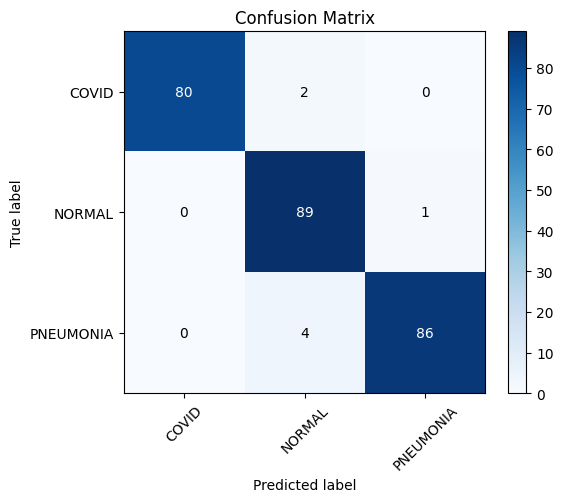

TEST acc         : 0.9732824427480916
TEST macro_f1    : 0.9738559651930649
TEST weighted_f1 : 0.9734346413520087
TEST per_class   : [{'precision': 1.0, 'recall': 0.975609756097561, 'f1': 0.9876543209876543, 'support': 82}, {'precision': 0.9368421052631579, 'recall': 0.9888888888888889, 'f1': 0.9621621621621621, 'support': 90}, {'precision': 0.9885057471264368, 'recall': 0.9555555555555556, 'f1': 0.9717514124293786, 'support': 90}]


{'acc': 0.9732824427480916,
 'micro_precision': 0.9732824427480916,
 'micro_recall': 0.9732824427480916,
 'micro_f1': 0.9732824427480916,
 'macro_precision': 0.9751159507965316,
 'macro_recall': 0.9733514001806686,
 'macro_f1': 0.9738559651930649,
 'weighted_precision': 0.9743561325002424,
 'weighted_recall': 0.9732824427480916,
 'weighted_f1': 0.9734346413520087,
 'per_class': [{'precision': 1.0,
   'recall': 0.975609756097561,
   'f1': 0.9876543209876543,
   'support': 82},
  {'precision': 0.9368421052631579,
   'recall': 0.9888888888888889,
   'f1': 0.9621621621621621,
   'support': 90},
  {'precision': 0.9885057471264368,
   'recall': 0.9555555555555556,
   'f1': 0.9717514124293786,
   'support': 90}],
 'confusion_matrix': tensor([[80,  2,  0],
         [ 0, 89,  1],
         [ 0,  4, 86]]),
 'logits': tensor([[-1.6454, -1.8139,  2.7517],
         [-1.7204,  2.4090, -0.7807],
         [ 2.9453, -1.5360, -0.6879],
         [ 3.0036, -0.7987, -0.6936],
         [-1.3675,  2.8249, -1.

In [ ]:
# load best model
ckpt = torch.load("checkpoints/resnet_b1_best.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_origin.load_state_dict(ckpt["model_state"])
else:
    model_resnet_origin.load_state_dict(ckpt)

model_resnet_origin.to(device)
model_resnet_origin.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_origin,
    test_enc_loader_b1,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

### B2 - abaltion

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import os

DATASET_ENCRYPTED_TRAIN_B2 = "/content/simple_non_learnable_baselines/B2_random_block_permutation"
ENC_TRAIN = DATASET_ENCRYPTED_TRAIN_B2

BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42


full_ds = ImageFolder(ENC_TRAIN)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=SEED
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(ENC_TRAIN, transform=tf_stats)
train_stats_ds = Subset(stats_ds_full, train_idx)

mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Compute mean/std:   0%|          | 0/74 [00:00<?, ?it/s]

mean_enc: [0.5015422701835632, 0.5016430020332336, 0.5018171072006226]
std_enc : [0.23951078951358795, 0.23951022326946259, 0.2395516037940979]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_TRAIN, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_TRAIN, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader_b2 = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader_b2 = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader_b2 = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))
print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)

# kiểm tra phân bố class từng split
train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 4705
val  : 261
test : 262
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1463 1622 1620]
val   class counts: [81 90 90]
test  class counts: [82 90 90]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_origin = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_origin,
    train_loader=train_enc_loader_b2,
    val_loader=val_enc_loader_b2,
    device=device,
    epochs=EPOCHS,
    mixup = False,
    lr=LR,
    weight_decay=1e-4,
    patience=5,
    csv_path="logs/resnet_b2_log.csv",
    best_path="checkpoints/resnet_b2_best.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.3809 acc 0.9116 || val loss 0.2883 acc 0.9579 macroF1 0.9579 | lr 3.00e-04 save


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.2840 acc 0.9531 || val loss 0.9088 acc 0.7280 macroF1 0.7107 | lr 2.99e-04


...

Epoch 09/50 | train loss 0.1957 acc 0.9893 || val loss 0.2173 acc 0.9808 macroF1 0.9815 | lr 2.77e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 10/50 | train loss 0.1889 acc 0.9942 || val loss 0.2190 acc 0.9808 macroF1 0.9808 | lr 2.71e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 11/50 | train loss 0.1873 acc 0.9940 || val loss 0.2159 acc 0.9808 macroF1 0.9813 | lr 2.66e-04
Early stopping at epoch 11 (best macroF1=0.9815)


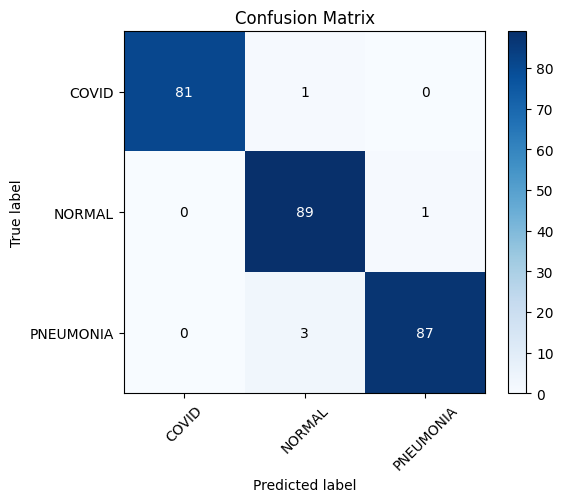

TEST acc         : 0.9809160305343512
TEST macro_f1    : 0.9813569053969675
TEST weighted_f1 : 0.9809749779075666
TEST per_class   : [{'precision': 1.0, 'recall': 0.9878048780487805, 'f1': 0.9938650306748467, 'support': 82}, {'precision': 0.956989247311828, 'recall': 0.9888888888888889, 'f1': 0.9726775956284154, 'support': 90}, {'precision': 0.9886363636363636, 'recall': 0.9666666666666667, 'f1': 0.9775280898876404, 'support': 90}]


{'acc': 0.9809160305343512,
 'micro_precision': 0.9809160305343512,
 'micro_recall': 0.9809160305343512,
 'micro_f1': 0.9809160305343512,
 'macro_precision': 0.9818752036493973,
 'macro_recall': 0.9811201445347787,
 'macro_f1': 0.9813569053969675,
 'weighted_precision': 0.9813217747531956,
 'weighted_recall': 0.9809160305343512,
 'weighted_f1': 0.9809749779075666,
 'per_class': [{'precision': 1.0,
   'recall': 0.9878048780487805,
   'f1': 0.9938650306748467,
   'support': 82},
  {'precision': 0.956989247311828,
   'recall': 0.9888888888888889,
   'f1': 0.9726775956284154,
   'support': 90},
  {'precision': 0.9886363636363636,
   'recall': 0.9666666666666667,
   'f1': 0.9775280898876404,
   'support': 90}],
 'confusion_matrix': tensor([[81,  1,  0],
         [ 0, 89,  1],
         [ 0,  3, 87]]),
 'logits': tensor([[-1.6922, -0.3763,  2.6864],
         [-1.0780,  3.3317, -1.3594],
         [ 2.9811, -1.2028, -1.4988],
         [ 3.2605, -1.4520, -1.6647],
         [-1.5795,  2.8230, -0.

In [ ]:
# load best model
ckpt = torch.load("checkpoints/resnet_b2_best.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_origin.load_state_dict(ckpt["model_state"])
else:
    model_resnet_origin.load_state_dict(ckpt)

model_resnet_origin.to(device)
model_resnet_origin.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_origin,
    test_enc_loader_b2,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

# Attack - Abaltion

In [ ]:
# ============================================================
# Two Attacks on Simple Non-learnable Baselines
# B1: Gaussian noise only
# B2: Random block permutation only
#
# The same original image is used as the metric reference for
# both B1 and B2.
# ============================================================

import os
import math
import subprocess
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# CONFIG
# ============================================================

# Folder ảnh gốc, bên trong có 3 folder nhãn.
ORIGINAL_ROOT = Path("/content/data_processed")

# Folder cha chứa hai dataset B1 và B2.
BASELINE_ROOT = Path("/content/simple_non_learnable_baselines")

BASELINE_DIRS = {
    "B1_gaussian_noise": BASELINE_ROOT / "B1_gaussian_noise",
    "B2_random_block_permutation": BASELINE_ROOT / "B2_random_block_permutation",
}

OUT_ROOT = Path("/content/attack_b1_b2_results")
OUT_IMG_ROOT = OUT_ROOT / "images"

OUT_DETAIL_CSV = OUT_ROOT / "attack_metrics_long.csv"
OUT_WIDE_CSV = OUT_ROOT / "attack_metrics_wide.csv"
OUT_FIG_PATH = OUT_ROOT / "attack_b1_b2_visual_grid.png"

# None: tự lấy ảnh đầu tiên trong TARGET_CLASS.
# Hoặc nhập relative path, ví dụ Path("NORMAL/NORMAL-1.png").
SAMPLE_REL_PATH = None

# False để chỉ lưu hình, không mở hình khi chạy.
SHOW_FIGURE = False

SUPPORTED_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}

IMAGE_SIZE = 224
NUM_CLASSES = 3

TARGET_CLASS = "NORMAL"

SEED = 42

# Gradient inversion config
MAX_ITERS = 800
LR = 0.1
TV_WEIGHT = 1e-4
L2_WEIGHT = 1e-6

LPIPS_NET = "alex"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_IMG_ROOT.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)


# ============================================================
# INSTALL / LOAD LPIPS
# ============================================================

try:
    import lpips
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lpips"])
    import lpips

lpips_model = lpips.LPIPS(net=LPIPS_NET).to(DEVICE)
lpips_model.eval()


# ============================================================
# SEED
# ============================================================

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# IMAGE LOAD / SAVE UTILS
# ============================================================

def load_image_array(path, image_size=224):
    img = cv2.imread(str(path))

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if image_size is not None:
        img = cv2.resize(img, (image_size, image_size))

    return img.astype(np.uint8)


def load_image_tensor(path, image_size=224, device="cuda"):
    tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    img = Image.open(path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)

    return x


def tensor_to_pil(x):
    x = torch.clamp(x.detach().cpu(), 0, 1)
    x = x.squeeze(0).permute(1, 2, 0).numpy()
    x = (x * 255).astype(np.uint8)
    return Image.fromarray(x)


def save_tensor_image(x, save_path):
    img = tensor_to_pil(x)
    img.save(save_path)


def save_array_image(img, save_path):
    Image.fromarray(img.astype(np.uint8)).save(save_path)


# ============================================================
# METRICS: PSNR / SSIM / LPIPS
# PSNR + SSIM use skimage standard implementation
# ============================================================

def compute_psnr_np(img1, img2):
    """
    Compute PSNR using skimage.
    img1, img2: RGB uint8, HWC
    Higher PSNR means two images are more similar.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    img1 = img1.astype(np.uint8)
    img2 = img2.astype(np.uint8)

    psnr = peak_signal_noise_ratio(
        img1,
        img2,
        data_range=255
    )

    return float(psnr)


def compute_ssim_np(img1, img2):
    """
    Compute SSIM using skimage.
    img1, img2: RGB uint8, HWC
    Higher SSIM means two images are structurally more similar.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    img1 = img1.astype(np.uint8)
    img2 = img2.astype(np.uint8)

    ssim = structural_similarity(
        img1,
        img2,
        channel_axis=2,
        data_range=255
    )

    return float(ssim)


def compute_lpips_np(img1, img2):
    """
    Compute LPIPS.
    img1, img2: RGB uint8, HWC
    LPIPS input should be in [-1, 1], BCHW.
    Higher LPIPS means two images are perceptually more different.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    x = torch.from_numpy(img1.astype(np.float32) / 255.0)
    y = torch.from_numpy(img2.astype(np.float32) / 255.0)

    x = x.permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    y = y.permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0

    x = x.to(DEVICE)
    y = y.to(DEVICE)

    with torch.no_grad():
        score = lpips_model(x, y).item()

    return float(score)


def compute_all_metrics(img_ref, img_out):
    """
    Compare img_out against img_ref.

    For privacy leakage evaluation:
    - lower PSNR  = less pixel-level similarity to original
    - lower SSIM  = less structural similarity to original
    - higher LPIPS = more perceptual difference from original
    """

    if img_ref.shape != img_out.shape:
        img_out = cv2.resize(img_out, (img_ref.shape[1], img_ref.shape[0]))

    img_ref = img_ref.astype(np.uint8)
    img_out = img_out.astype(np.uint8)

    psnr = compute_psnr_np(img_ref, img_out)
    ssim = compute_ssim_np(img_ref, img_out)
    lpips_score = compute_lpips_np(img_ref, img_out)

    return {
        "PSNR": psnr,
        "SSIM": ssim,
        "LPIPS": lpips_score,
    }

# ============================================================
# ATTACK 1: CIPHERTEXT-ONLY ADVANCED ATTACK
# ============================================================

def check_image(img, name="img"):
    if img is None:
        raise ValueError(f"{name} is None. Make sure cv2.imread(...) loaded successfully.")

    if not isinstance(img, np.ndarray):
        raise TypeError(f"{name} must be a numpy array")

    if img.ndim != 3 or img.shape[2] != 3:
        raise ValueError(f"{name} must have shape (H, W, 3), got {img.shape}")


def generate_candidates(pixel):
    p0, p1, p2 = [int(x) for x in pixel]

    perms = np.array([
        [p0, p1, p2],
        [p0, p2, p1],
        [p1, p0, p2],
        [p1, p2, p0],
        [p2, p0, p1],
        [p2, p1, p0],
    ], dtype=np.int16)

    candidates = np.zeros((6, 8, 3), dtype=np.int16)

    for r in range(6):
        base = perms[r]

        for bf in range(8):
            b3 = bf % 2
            b2 = (bf // 2) % 2
            b1 = (bf // 4) % 2

            candidates[r, bf, 0] = base[0] if b1 == 0 else (base[0] ^ 255)
            candidates[r, bf, 1] = base[1] if b2 == 0 else (base[1] ^ 255)
            candidates[r, bf, 2] = base[2] if b3 == 0 else (base[2] ^ 255)

    return candidates


def attack_ciphertext_only_advanced(enc_img, initial_pixel=(128, 128, 128)):
    check_image(enc_img, "enc_img")

    h, w, _ = enc_img.shape

    dec = np.zeros_like(enc_img)
    dec[0, 0] = np.array(initial_pixel, dtype=np.uint8)

    for j in range(1, w):
        ref = dec[0, j - 1].astype(np.int16)
        cand = generate_candidates(enc_img[0, j])

        diff = np.abs(cand - ref).sum(axis=2)
        r, c = np.unravel_index(np.argmin(diff), diff.shape)

        dec[0, j] = cand[r, c].astype(np.uint8)

    for i in range(1, h):
        for j in range(w):
            ref = dec[i - 1, j].astype(np.int16)
            cand = generate_candidates(enc_img[i, j])

            diff = np.abs(cand - ref).sum(axis=2)
            r, c = np.unravel_index(np.argmin(diff), diff.shape)

            dec[i, j] = cand[r, c].astype(np.uint8)

    return dec


def run_cipher_attack(img_path, save_dir, file_prefix):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    input_img = load_image_array(img_path, image_size=IMAGE_SIZE)

    cipher_recovered = attack_ciphertext_only_advanced(input_img)

    input_path = save_dir / f"{file_prefix}_input.png"
    recovered_path = save_dir / f"{file_prefix}_cipher_recovered.png"
    diff_path = save_dir / f"{file_prefix}_cipher_absdiff.png"

    diff = np.abs(
        input_img.astype(np.int16)
        - cipher_recovered.astype(np.int16)
    ).astype(np.uint8)

    save_array_image(input_img, input_path)
    save_array_image(cipher_recovered, recovered_path)
    save_array_image(diff, diff_path)

    return {
        "input_path": str(input_path),
        "recovered_path": str(recovered_path),
        "diff_path": str(diff_path),
    }


# ============================================================
# ATTACK 2: GRADIENT INVERSION ATTACK
# ============================================================

def total_variation(x):
    dh = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    dw = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return dh + dw


def gradient_cosine_loss(dummy_grads, target_grads):
    num = 0.0
    den1 = 0.0
    den2 = 0.0

    for dg, tg in zip(dummy_grads, target_grads):
        num = num + (dg * tg).sum()
        den1 = den1 + (dg * dg).sum()
        den2 = den2 + (tg * tg).sum()

    return 1 - num / (torch.sqrt(den1) * torch.sqrt(den2) + 1e-12)


def compute_mse_tensor(img1, img2):
    img1 = torch.clamp(img1, 0, 1)
    img2 = torch.clamp(img2, 0, 1)

    return torch.mean((img1 - img2) ** 2).item()


def compute_psnr_tensor(img1, img2):
    mse = compute_mse_tensor(img1, img2)

    if mse == 0:
        return float("inf")

    return 10.0 * math.log10(1.0 / mse)


def build_attack_model(num_classes=3):
    weights = ResNet18_Weights.DEFAULT

    model = resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model = model.to(DEVICE)
    model.eval()

    return model


# Build one fixed attack model for fairness
set_seed(SEED)
ATTACK_MODEL = build_attack_model(num_classes=NUM_CLASSES)


def run_gradient_inversion_attack(
    img_path,
    label,
    save_dir,
    file_prefix,
    max_iters=800,
    lr=0.1,
    tv_weight=1e-4,
    l2_weight=1e-6
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    gt_data = load_image_tensor(
        img_path,
        image_size=IMAGE_SIZE,
        device=DEVICE
    )

    gt_label = torch.tensor(
        [label],
        dtype=torch.long,
        device=DEVICE
    )

    model = ATTACK_MODEL
    criterion = nn.CrossEntropyLoss()

    model.zero_grad(set_to_none=True)

    out = model(gt_data)
    target_loss = criterion(out, gt_label)

    target_grads = torch.autograd.grad(
        target_loss,
        model.parameters()
    )

    target_grads = [
        g.detach().clone()
        for g in target_grads
    ]

    dummy_data = torch.randn_like(
        gt_data,
        device=DEVICE,
        requires_grad=True
    )

    optimizer = optim.Adam(
        [dummy_data],
        lr=lr
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[
            max_iters // 2,
            int(max_iters * 0.75)
        ],
        gamma=0.3
    )

    best_psnr = -1e9
    best_dummy = None
    best_iter = -1
    best_loss = None

    for it in range(1, max_iters + 1):
        optimizer.zero_grad(set_to_none=True)

        dummy_clamped = torch.sigmoid(dummy_data)

        pred = model(dummy_clamped)
        dummy_loss_ce = criterion(pred, gt_label)

        dummy_grads = torch.autograd.grad(
            dummy_loss_ce,
            model.parameters(),
            create_graph=True
        )

        grad_loss = gradient_cosine_loss(
            dummy_grads,
            target_grads
        )

        tv_loss = total_variation(dummy_clamped)
        l2_loss = torch.mean(dummy_clamped ** 2)

        total_loss = (
            grad_loss
            + tv_weight * tv_loss
            + l2_weight * l2_loss
        )

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            current_dummy = torch.sigmoid(dummy_data)
            current_psnr = compute_psnr_tensor(gt_data, current_dummy)

            if current_psnr > best_psnr:
                best_psnr = current_psnr
                best_dummy = current_dummy.detach().clone()
                best_iter = it
                best_loss = total_loss.item()

    recovered_path = save_dir / f"{file_prefix}_gradient_recovered.png"
    diff_path = save_dir / f"{file_prefix}_gradient_absdiff.png"

    final_dummy = best_dummy

    abs_diff = torch.abs(
        torch.clamp(gt_data, 0, 1)
        - torch.clamp(final_dummy, 0, 1)
    )

    save_tensor_image(final_dummy, recovered_path)
    save_tensor_image(
        abs_diff / (abs_diff.max() + 1e-8),
        diff_path
    )

    final_mse = compute_mse_tensor(gt_data, final_dummy)
    final_psnr = compute_psnr_tensor(gt_data, final_dummy)

    return {
        "best_iter": best_iter,
        "best_loss": best_loss,
        "attack_mse": final_mse,
        "attack_psnr": final_psnr,
        "recovered_path": str(recovered_path),
        "diff_path": str(diff_path),
    }


# ============================================================
# SELECT ONE SAMPLE FROM ORIGINAL DATASET
# ============================================================

def resolve_matching_baseline_image(baseline_root, rel_path):
    """
    Tìm đúng ảnh B1/B2 tương ứng với ảnh gốc.

    Hỗ trợ trường hợp ảnh gốc là .jpg nhưng code sinh baseline
    đã lưu kết quả thành .png.
    """
    baseline_root = Path(baseline_root)
    rel_path = Path(rel_path)

    exact_path = baseline_root / rel_path
    if exact_path.is_file():
        return exact_path

    png_path = baseline_root / rel_path.with_suffix(".png")
    if png_path.is_file():
        return png_path

    target_dir = baseline_root / rel_path.parent
    if target_dir.is_dir():
        matches = sorted(
            p for p in target_dir.iterdir()
            if p.is_file()
            and p.stem == rel_path.stem
            and p.suffix.lower() in SUPPORTED_EXTENSIONS
        )

        if len(matches) == 1:
            return matches[0]

        if len(matches) > 1:
            raise RuntimeError(
                f"Multiple matching files for {rel_path} in {baseline_root}:\n"
                + "\n".join(str(p) for p in matches)
            )

    raise FileNotFoundError(
        "Cannot find matching baseline image.\n"
        f"Baseline root: {baseline_root}\n"
        f"Relative path: {rel_path}"
    )


def choose_one_original_sample(
    original_root,
    target_class="NORMAL",
    sample_rel_path=None,
):
    """
    Chọn ảnh từ ORIGINAL_ROOT, không chọn từ B1 hoặc B2.
    B1 và B2 sau đó được lấy bằng cùng relative path.
    """
    original_root = Path(original_root)
    ds = ImageFolder(str(original_root))

    if target_class not in ds.class_to_idx:
        raise ValueError(
            f"Cannot find class {target_class}. "
            f"Available classes: {ds.classes}"
        )

    if sample_rel_path is not None:
        rel_path = Path(sample_rel_path)
        original_path = original_root / rel_path

        if not original_path.is_file():
            raise FileNotFoundError(
                f"Cannot find SAMPLE_REL_PATH: {original_path}"
            )

        class_name = rel_path.parts[0]
        if class_name not in ds.class_to_idx:
            raise ValueError(
                f"Invalid class folder {class_name}. "
                f"Available classes: {ds.classes}"
            )

        label = ds.class_to_idx[class_name]

    else:
        target_label = ds.class_to_idx[target_class]
        original_path = None
        rel_path = None
        label = None
        class_name = target_class

        for path, current_label in ds.samples:
            if current_label == target_label:
                original_path = Path(path)
                rel_path = original_path.relative_to(original_root)
                label = int(current_label)
                break

        if original_path is None:
            raise RuntimeError(
                f"No image found for class {target_class}"
            )

    sample = {
        "original_path": str(original_path),
        "rel_path": str(rel_path),
        "label": int(label),
        "class_name": class_name,
    }

    print("Selected sample:", sample)
    print("Classes:", ds.classes)
    print("class_to_idx:", ds.class_to_idx)

    return sample, ds.classes, ds.class_to_idx


# ============================================================
# PLOT GRID: 3 COLUMNS
# ============================================================

def plot_attack_grid(rows, save_path):
    """
    3 image columns:
    Baseline Input | Cipher Attack | Gradient Attack
    """
    df = pd.DataFrame(rows)
    n = len(df)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=3,
        figsize=(12, 3.2 * n)
    )

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    col_titles = [
        "Baseline Input",
        "Ciphertext-only Attack",
        "Gradient Inversion Attack"
    ]

    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight="bold")

    for i, row in df.iterrows():
        input_img = load_image_array(
            row["input_path"], image_size=IMAGE_SIZE
        )
        cipher_img = load_image_array(
            row["cipher_recovered_path"], image_size=IMAGE_SIZE
        )
        grad_img = load_image_array(
            row["gradient_recovered_path"], image_size=IMAGE_SIZE
        )

        for j, img in enumerate([input_img, cipher_img, grad_img]):
            axes[i, j].imshow(img)
            axes[i, j].axis("off")

        axes[i, 0].set_ylabel(
            row["baseline"],
            fontsize=11,
            rotation=0,
            labelpad=70,
            va="center",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")

    if SHOW_FIGURE:
        plt.show()

    plt.close(fig)
    print("Saved figure:", save_path)


# ============================================================
# RUN B1 AND B2
# ============================================================

def run_two_attacks_b1_b2():
    if not ORIGINAL_ROOT.is_dir():
        raise FileNotFoundError(
            f"ORIGINAL_ROOT does not exist: {ORIGINAL_ROOT}"
        )

    for baseline_name, baseline_root in BASELINE_DIRS.items():
        if not baseline_root.is_dir():
            raise FileNotFoundError(
                f"Missing {baseline_name}: {baseline_root}"
            )

    sample, classes, class_to_idx = choose_one_original_sample(
        ORIGINAL_ROOT,
        target_class=TARGET_CLASS,
        sample_rel_path=SAMPLE_REL_PATH,
    )

    rel_path = Path(sample["rel_path"])
    label = sample["label"]
    class_name = sample["class_name"]

    # QUAN TRỌNG: reference luôn là ảnh gốc thật.
    original_path = Path(sample["original_path"])
    original_img = load_image_array(
        original_path,
        image_size=IMAGE_SIZE
    )

    original_saved_path = OUT_IMG_ROOT / "original_reference.png"
    save_array_image(original_img, original_saved_path)

    rows_for_plot = []
    metric_rows = []

    safe_stem = (
        rel_path
        .with_suffix("")
        .as_posix()
        .replace("/", "_")
    )

    for baseline_name, baseline_root in tqdm(
        BASELINE_DIRS.items(),
        desc="Baselines"
    ):
        # Lấy đúng B1/B2 có cùng relative path với ảnh gốc.
        img_path = resolve_matching_baseline_image(
            baseline_root,
            rel_path,
        )

        print(f"\n[{baseline_name}]")
        print("Original:", original_path)
        print("Baseline:", img_path)

        file_prefix = f"{baseline_name}_{safe_stem}"
        save_dir = OUT_IMG_ROOT / baseline_name
        save_dir.mkdir(parents=True, exist_ok=True)

        input_img = load_image_array(
            img_path,
            image_size=IMAGE_SIZE
        )
        input_path_saved = (
            save_dir / f"{file_prefix}_baseline_input.png"
        )
        save_array_image(input_img, input_path_saved)

        cipher_result = run_cipher_attack(
            img_path=img_path,
            save_dir=save_dir,
            file_prefix=file_prefix
        )

        gradient_result = run_gradient_inversion_attack(
            img_path=img_path,
            label=label,
            save_dir=save_dir,
            file_prefix=file_prefix,
            max_iters=MAX_ITERS,
            lr=LR,
            tv_weight=TV_WEIGHT,
            l2_weight=L2_WEIGHT
        )

        cipher_img = load_image_array(
            cipher_result["recovered_path"],
            image_size=IMAGE_SIZE
        )

        gradient_img = load_image_array(
            gradient_result["recovered_path"],
            image_size=IMAGE_SIZE
        )

        # Tất cả metric đều so với đúng original_img.
        input_metrics = compute_all_metrics(original_img, input_img)
        cipher_metrics = compute_all_metrics(original_img, cipher_img)
        gradient_metrics = compute_all_metrics(original_img, gradient_img)

        metric_rows.extend([
            {
                "baseline": baseline_name,
                "class_name": class_name,
                "relative_path": rel_path.as_posix(),
                "attack": "transformed_input",
                **input_metrics,
            },
            {
                "baseline": baseline_name,
                "class_name": class_name,
                "relative_path": rel_path.as_posix(),
                "attack": "ciphertext_only_advanced",
                **cipher_metrics,
            },
            {
                "baseline": baseline_name,
                "class_name": class_name,
                "relative_path": rel_path.as_posix(),
                "attack": "gradient_inversion",
                **gradient_metrics,
            },
        ])

        rows_for_plot.append({
            "baseline": baseline_name,
            "input_path": str(input_path_saved),
            "cipher_recovered_path": cipher_result["recovered_path"],
            "gradient_recovered_path": gradient_result["recovered_path"],
        })

        # Save tạm sau mỗi baseline.
        pd.DataFrame(metric_rows).to_csv(
            OUT_DETAIL_CSV,
            index=False
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    df_long = pd.DataFrame(metric_rows)
    df_long.to_csv(OUT_DETAIL_CSV, index=False)

    df_wide = df_long.pivot(
        index=["baseline", "class_name", "relative_path"],
        columns="attack",
        values=["PSNR", "SSIM", "LPIPS"]
    )

    df_wide.columns = [
        f"{attack}_{metric}"
        for metric, attack in df_wide.columns
    ]

    df_wide = df_wide.reset_index()
    df_wide.to_csv(OUT_WIDE_CSV, index=False)

    print("Saved detail CSV:", OUT_DETAIL_CSV)
    print("Saved wide CSV:", OUT_WIDE_CSV)
    print("Original reference:", original_saved_path)

    display(df_long)
    display(df_wide)

    plot_attack_grid(
        rows_for_plot,
        save_path=OUT_FIG_PATH
    )

    return df_long, df_wide


df_attack_long, df_attack_wide = run_two_attacks_b1_b2()

Device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 244MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

Baselines:   0%|          | 0/2 [00:00<?, ?it/s]


[B1_gaussian_noise]
Original: /content/data_processed/NORMAL/001626.png
Baseline: /content/simple_non_learnable_baselines/B1_gaussian_noise/NORMAL/001626.png

[B2_random_block_permutation]
Original: /content/data_processed/NORMAL/001626.png
Baseline: /content/simple_non_learnable_baselines/B2_random_block_permutation/NORMAL/001626.png
Saved detail CSV: /content/attack_b1_b2_results/attack_metrics_long.csv
Saved wide CSV: /content/attack_b1_b2_results/attack_metrics_wide.csv
Original reference: /content/attack_b1_b2_results/images/original_reference.png


,baseline,class_name,relative_path,attack,PSNR,SSIM,LPIPS
0,B1_gaussian_noise,NORMAL,NORMAL/001626.png,transformed_input,22.409281,0.365751,0.573390
1,B1_gaussian_noise,NORMAL,NORMAL/001626.png,ciphertext_only_advanced,8.077944,0.136012,0.874040
2,B1_gaussian_noise,NORMAL,NORMAL/001626.png,gradient_inversion,8.964798,0.016203,1.385756
3,B2_random_block_permutation,NORMAL,NORMAL/001626.png,transformed_input,7.442623,0.124510,0.797663
4,B2_random_block_permutation,NORMAL,NORMAL/001626.png,ciphertext_only_advanced,8.561737,0.173013,0.744868
5,B2_random_block_permutation,NORMAL,NORMAL/001626.png,gradient_inversion,8.955451,0.016354,1.409495


,baseline,class_name,relative_path,ciphertext_only_advanced_PSNR,gradient_inversion_PSNR,transformed_input_PSNR,ciphertext_only_advanced_SSIM,gradient_inversion_SSIM,transformed_input_SSIM,ciphertext_only_advanced_LPIPS,gradient_inversion_LPIPS,transformed_input_LPIPS
0,B1_gaussian_noise,NORMAL,NORMAL/001626.png,8.077944,8.964798,22.409281,0.136012,0.016203,0.365751,0.874040,1.385756,0.573390
1,B2_random_block_permutation,NORMAL,NORMAL/001626.png,8.561737,8.955451,7.442623,0.173013,0.016354,0.124510,0.744868,1.409495,0.797663


Saved figure: /content/attack_b1_b2_results/attack_b1_b2_visual_grid.png
